Numba imported
73705


/home/skelly/school/spices/pytorch_implementation/double_gmm.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/home/skelly/school/spices/pytorch_implementation/double_gmm.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/home/skelly/school/spices/pytorch_implementation/double_gmm.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

Cluster 0 Center: x=4100.03, y=4102.20
Cluster 1 Center: x=4101.35, y=4098.82
Cluster 0 Spread (Scaled Units): x_std=0.33, y_std=0.84, theta=336.10
Cluster 1 Spread (Scaled Units): x_std=1.05, y_std=1.14, theta=76.04
Background table should be larger than sources table.
Cluster 0 Center: x=4102.42, y=4098.76
Cluster 1 Center: x=4091.52, y=4099.56
Cluster 2 Center: x=4109.10, y=4098.13
Cluster 3 Center: x=4100.46, y=4099.16
Cluster 0 Spread (Scaled Units): x_std=0.90, y_std=0.98, theta=12.67
Cluster 1 Spread (Scaled Units): x_std=0.46, y_std=1.08, theta=0.81
Cluster 2 Spread (Scaled Units): x_std=0.63, y_std=1.02, theta=359.02
Cluster 3 Spread (Scaled Units): x_std=0.54, y_std=0.88, theta=353.18
Cluster 0 Center: x=4102.93, y=4093.06
Cluster 1 Center: x=4102.48, y=4112.01
Cluster 2 Center: x=4096.11, y=4096.07
Cluster 3 Center: x=4103.01, y=4107.88
Cluster 0 Spread (Scaled Units): x_std=0.14, y_std=0.30, theta=88.89
Cluster 1 Spread (Scaled Units): x_std=0.18, y_std=0.27, theta=86.45
Cl

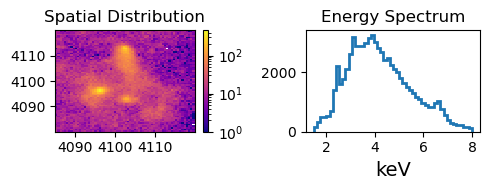

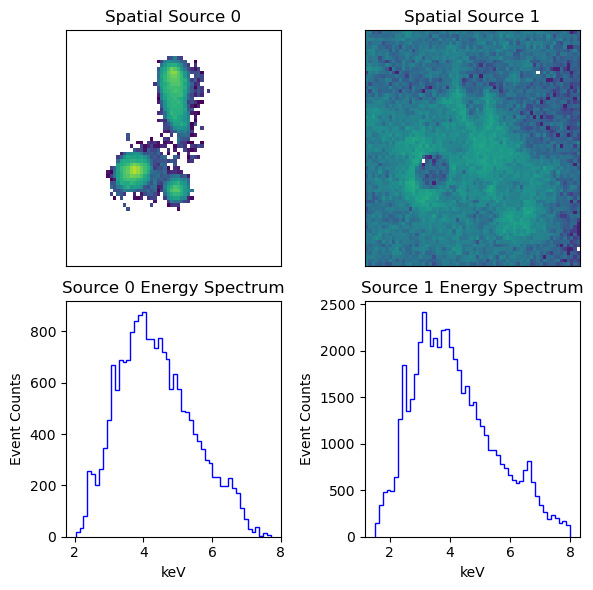

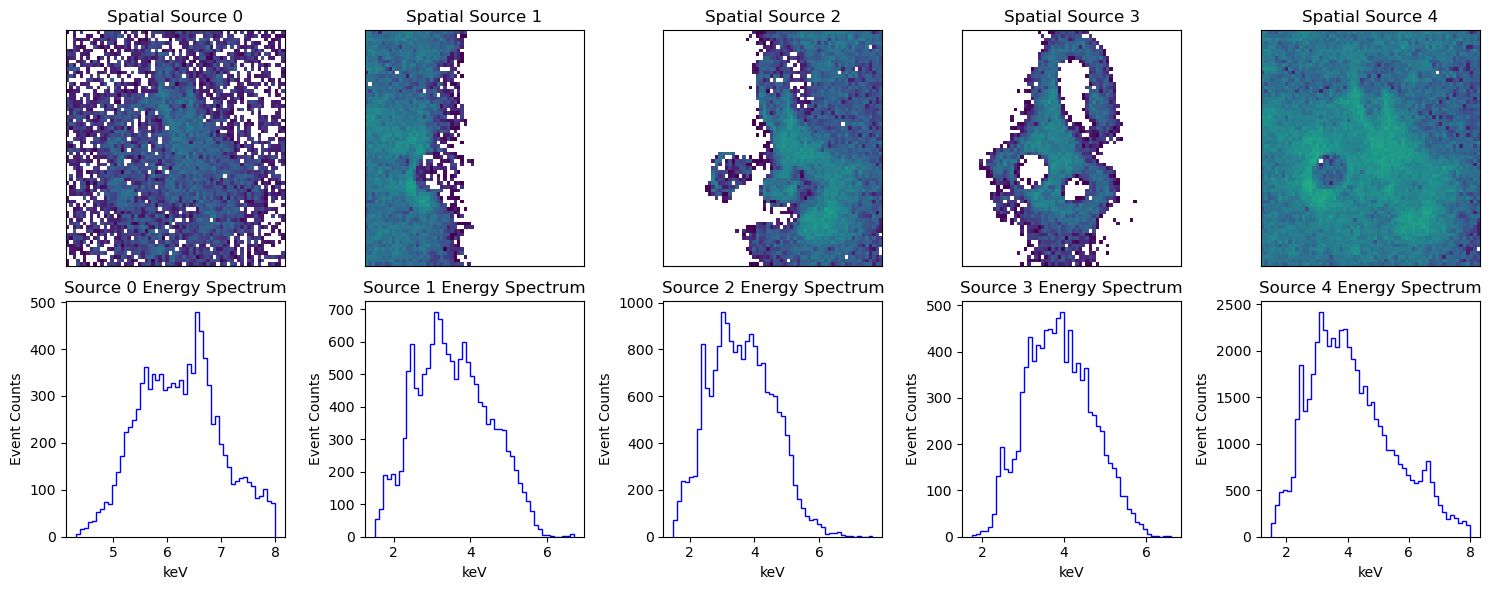

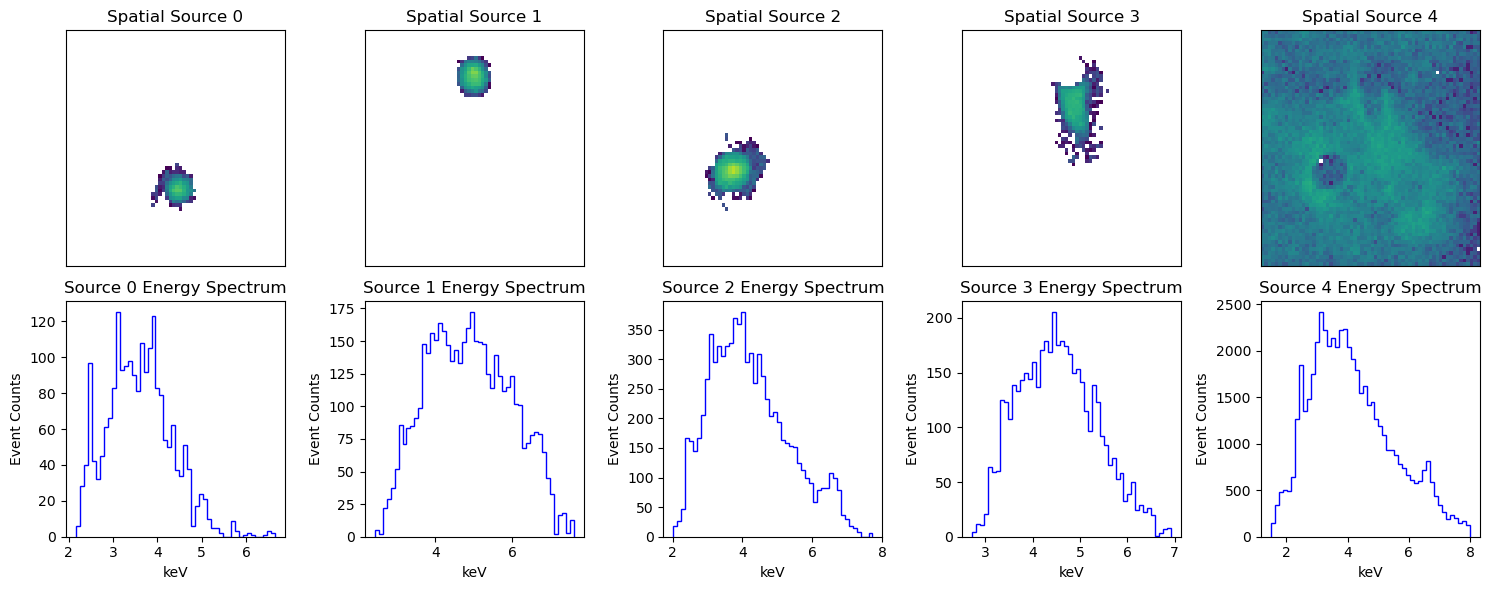

In [1]:
from double_gmm import *

In [2]:
import matplotlib as mpl
from matplotlib.path import Path
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [3]:
def gaussian(x, y, x0, y0, xalpha, yalpha, A):
        return A * np.exp( -((x-x0)/xalpha)**2 -((y-y0)/yalpha)**2)

def _gaussian(M, *args):
    x, y = M
    arr = np.zeros(x.shape)
    for i in range(len(args)//5):
        arr += gaussian(x, y, *args[i*5:i*5+5])
    return arr

def fit_contours_2d(table, initial_center, initial_std):
    counts, xedges, yedges = np.histogram2d(
        table['x'], table['y'], 
        bins=[BINX, BINY], weights=table['energy']
    )

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))
    zdata_flat = counts.T.ravel()

    # --- Smart Initialization for 2 Gaussians ---
    x0, y0 = initial_center[0], initial_center[1]
    sx, sy = max(initial_std[0], 0.5), max(initial_std[1], 0.5)
    A_max = np.max(counts) if np.max(counts) > 0 else 1.0

    # Gaussian 1: The Core (at the GMM center)
    g1 = [x0, y0, sx, sy, A_max * 0.7]
    
    # Gaussian 2: The "Blobby" Offset (slightly shifted to help the fit start)
    # We shift it by half a sigma to give the solver a direction to pull
    g2 = [x0 + (sx/2), y0 + (sy/2), sx, sy, A_max * 0.3]
    
    p0 = g1 + g2

    # --- Tight Bounds to prevent RuntimeError ---
    # [x0, y0, sx, sy, A] repeated twice
    dist_tol = 15.0 # pixels/units
    
    # Define bounds for one set of 5 parameters
    low_block = [x0 - dist_tol, y0 - dist_tol, 0.1, 0.1, 0]
    high_block = [x0 + dist_tol, y0 + dist_tol, sx * 10, sy * 10, A_max * 2]
    
    lower = low_block * 2
    upper = high_block * 2

    try:
        # Increase maxfev and use a robust method
        popt, pcov = curve_fit(
            _gaussian, 
            xdata_flat, 
            zdata_flat, 
            p0=p0, 
            bounds=(lower, upper),
            maxfev=10000 
        )
    except RuntimeError:
        print(f"Fit failed for source at {x0, y0}. Using GMM priors.")
        return p0 # Return the 10 initial guess parameters as a fallback
        
    return popt

In [4]:
contours = []
cont_lvls = 15

for i in range(len(split_sources)):
    table = split_sources[i]
    
    # PASS THE GMM RESULTS HERE
    # centers[i] is the [x, y] for this specific source
    # std_dev[i] is the [sx, sy, theta] for this specific source
    popt = fit_contours_2d(table, centers[i], std_dev[i])
    
    # Re-calculate grid for plotting the contour
    counts, xedges, yedges = np.histogram2d(
        table['x'], table['y'], 
        bins=[BINX, BINY], weights=table['energy']
    )
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))

    # Generate the fitted surface
    fit_grid = _gaussian(xdata_flat, *popt).reshape(len(y_centers), len(x_centers))
    
    # Plot
    cont = ax1.contour(X, Y, fit_grid, levels=cont_lvls, colors='white', linewidths=0.8, alpha=0.7)
    contours.append(cont)

In [5]:
def area_of_contour(contour_collection, lvl: int):
    try:
        x = contour_collection.get_paths()[lvl].vertices[:,0]
        y = contour_collection.get_paths()[lvl].vertices[:,1]
    except:
        return np.inf
    # Standard Shoelace Formula
    # we sum (x_i * y_{i+1}) - (y_i * x_{i+1})
    area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
    return area

def area_of_contour_ring(contour_collection, lvl: int):
    current = area_of_contour(contour_collection, lvl)
    if lvl == 0:
        return current
    
    prev_area = area_of_contour(contour_collection, lvl - 1)
    return np.abs(current - prev_area)

def energy_of_contour(contour_collection, data, lvl: int, separated=True):
    try:
        vert = contour_collection.get_paths()[lvl].vertices
    except:
        return np.nan
    
    contour_path = Path(vert)
    points = data[['x', 'y']].values
    mask = contour_path.contains_points(points)
    if separated:
        total_energy = (data.loc[mask, 'energy'] * data.loc[mask, 'weight']).sum()
    else: 
        total_energy = data.loc[mask, 'energy'].sum()
    return total_energy

def energy_of_contour_ring(contour_collection, data, lvl: int, separated=True):
    current = energy_of_contour(contour_collection, data, lvl, separated)
    if lvl == 0:
        return current
    return np.abs(current - energy_of_contour(contour_collection, data, lvl - 1, separated))
    
def energy_density_ring(contour_collection, data, lvl: int, separated=True):
    return energy_of_contour_ring(contour_collection, data, lvl, separated) / area_of_contour_ring(contour_collection, lvl)


Area Source 0: [np.float64(10.70918893814087), np.float64(6.317869663238525), np.float64(4.552507638931274), np.float64(3.5962579250335693), np.float64(3.000971794128418), np.float64(2.601522445678711), np.float64(2.3185582160949707), np.float64(2.115999698638916), np.float64(1.9767146110534668), np.float64(1.8939430713653564), np.float64(1.8849124908447266), np.float64(2.0648770332336426), np.float64(1.8876537680625916)]
Energy Source 0: [np.float64(51889.65285361581), np.float64(107579.33533549441), np.float64(169581.67434314778), np.float64(239687.08769501792), np.float64(321788.42928025033), np.float64(380835.1946000571), np.float64(418026.77781499986), np.float64(534106.2943927464), np.float64(618876.0240465193), np.float64(602652.0535579532), np.float64(779291.0045412137), np.float64(752257.4236187774), np.float64(716354.9285054404)]
Area Source 1: [np.float64(8.30530571937561), np.float64(3.5797747373580933), np.float64(1.4816346168518066), np.float64(0.800469160079956), np.floa

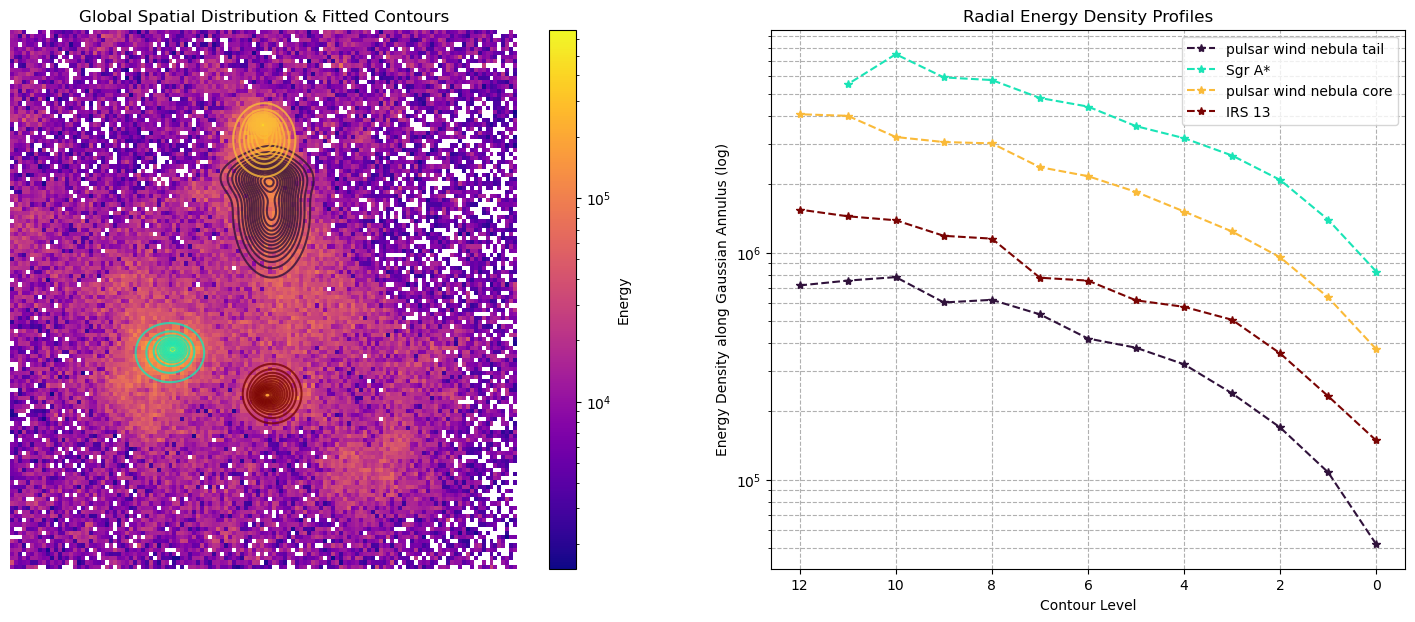

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 weights=subset['energy'],
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Global Spatial Distribution & Fitted Contours')
ax1.set_axis_off()
ax2.set_title('Radial Energy Density Profiles')
ax2.set_xlabel('Contour Level')
ax2.set_ylabel('Energy Density along Gaussian Annulus (log)')
ax2.invert_xaxis()
fig.colorbar(h2d[3], ax=ax1, label='Energy')

areas = []
energies = []
cmap = mpl.colormaps['turbo']
colors = cmap(np.linspace(0, 1, len(contours)))
objs = ['pulsar wind nebula tail','Sgr A*', 'pulsar wind nebula core', 'IRS 13']
for obj, cont in enumerate(contours):
    ax1.contour(cont, colors=colors[obj], alpha=0.8)
    areas.append([area_of_contour_ring(cont, i) for i in range(2, cont_lvls)])
    energies.append([energy_density_ring(cont, split_sources[obj], i) for i in range(2, cont_lvls)])
    ax2.plot(energies[-1], color=colors[obj], label=objs[obj], marker='*', linestyle='dashed')
    #plt.plot([energy_of_contour_ring(cont, split_sources[obj], i) for i in range(cont_lvls)], '--')

plt.grid(linestyle='--', which='both')
plt.legend()
plt.yscale('log')
for i, a in enumerate(areas):
    print(f"Area Source {i}: {areas[i]}")
    print(f"Energy Source {i}: {energies[i]}")
    

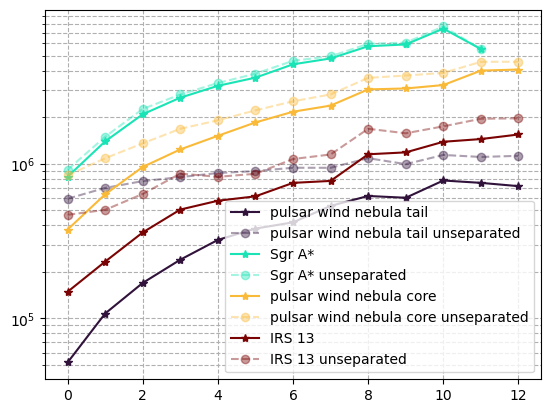

In [7]:
tab_energies = []
cmap = mpl.colormaps['turbo']
colors = cmap(np.linspace(0, 1, len(contours)))
objs = ['pulsar wind nebula tail','Sgr A*', 'pulsar wind nebula core', 'IRS 13']
for obj, cont in enumerate(contours):
    ax1.contour(cont, colors=colors[obj], alpha=0.8)
    tab_energies.append([energy_density_ring(cont, subset, i, separated=False) for i in range(2, cont_lvls)])
    plt.plot(energies[obj], color=colors[obj], label=objs[obj], marker='*')
    plt.plot(tab_energies[-1], color=colors[obj], label=f'{objs[obj]} unseparated', marker='o', linestyle='dashed', alpha=0.4)

plt.grid(linestyle='--', which='both')
plt.legend()
plt.yscale('log')
    

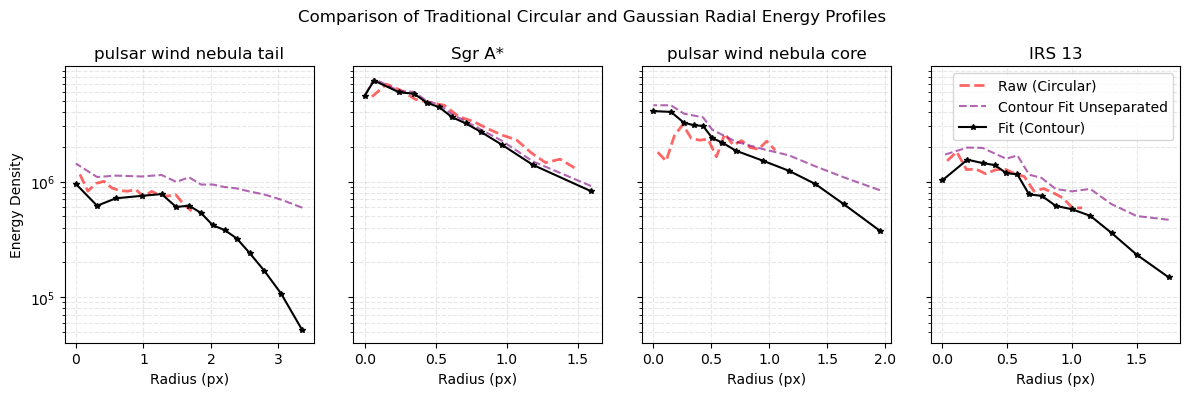

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_profiles(split_sources, contours, centers, std_devs, num_bins=15):
    """
    Creates a 4-panel subplot comparing Contour vs. Circular radial profiles.
    """
    num_sources = min(len(split_sources), 4)
    fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
    fig.suptitle("Comparison of Traditional Circular and Gaussian Radial Energy Profiles ")
    
    # If there's only 1 source, axes won't be an array, so we wrap it
    if num_sources == 1:
        axes = [axes]

    for i in range(num_sources):
        ax = axes[i]
        table = split_sources[i]
        cont_coll = contours[i]
        center = centers[i]
        
        # std_devs[i] is usually [sig_x, sig_y, theta]
        sig_max = max(std_devs[i][0], std_devs[i][1])
        
        # --- 1. Circular Aperture Profile (Raw Data) ---
        max_r = 4 * sig_max
        x0, y0 = center[0], center[1]
        dist = np.sqrt((table['x'] - x0)**2 + (table['y'] - y0)**2)
        
        bin_edges = np.linspace(0, max_r, num_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        circ_densities = []
        
        for j in range(num_bins):
            mask = (dist >= bin_edges[j]) & (dist < bin_edges[j+1])
            area = np.pi * (bin_edges[j+1]**2 - bin_edges[j]**2)
            energy = table.loc[mask, 'energy'].sum()
            circ_densities.append(energy / area if area > 0 else 0)

        # 2D Gaussian Contour Ring Profile
        # Skip lvl 0 and 1 to avoid the "total disk" artifact
        lvls = range(2, len(cont_coll.get_paths()))
        cont_radii = []
        cont_densities = []
        cont_unsep_densities = []
        
        for l in lvls:
            a_ring = area_of_contour_ring(cont_coll, l)
            e_ring = energy_of_contour_ring(cont_coll, table, l)
            e_ring_unseparated = energy_of_contour_ring(cont_coll, subset, l, separated=False)
            
            total_area = area_of_contour(cont_coll, l)
            r_eq = np.sqrt(total_area / np.pi)
            
            cont_radii.append(r_eq)
            cont_densities.append(e_ring / a_ring)
            cont_unsep_densities.append(e_ring_unseparated / a_ring)


        ax.plot(bin_centers, circ_densities, label='Raw (Circular)', alpha=0.6, lw=2, color='red', linestyle='dashed')
        ax.plot(cont_radii, cont_unsep_densities, color='purple', label=f'Contour Fit Unseparated', linestyle='dashed', alpha=0.6)
        ax.plot(cont_radii, cont_densities, '*-', color='black', label='Fit (Contour)', markersize=4)

        ax.set_title(f"{objs[i]}")
        ax.set_xlabel("Radius (px)")
        if i == 0:
            ax.set_ylabel("Energy Density")
        
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', alpha=0.3)
        if i == num_sources - 1:
            ax.legend()
            
    plt.tight_layout()
    plt.savefig('output/profile_comparison.png')

# To run:
plot_all_profiles(split_sources, contours, centers, std_dev)

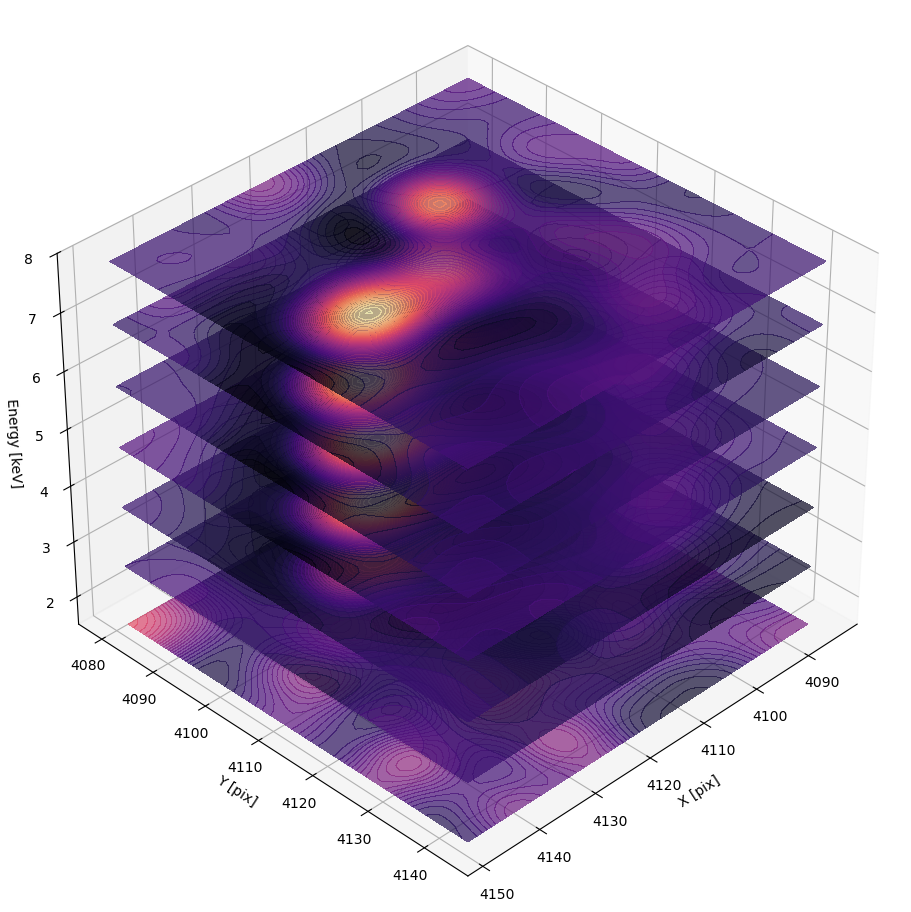

In [105]:
total_bands = cube.shape[0]
energy_values = np.linspace(EMIN, EMAX, total_bands) / 1e3
skip = max(1, cube.shape[2] // BINX)
original_res = cube.shape[2]
x_coords = np.arange(XMIN, XMIN + original_res, skip)
y_coords = np.arange(YMIN, YMIN + cube.shape[3], skip)
X, Y = np.meshgrid(x_coords, y_coords)

fig = plt.figure(figsize=(12, 9), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

step = 8
for i in range(0, total_bands, step):
    actual_energy = energy_values[i]  # Get the physical energy value
    slice_data = cube[i, 3]
    
    ax.contourf(X, Y, slice_data, 
                zdir='z', 
                offset=actual_energy, 
                cmap='magma', 
                levels=50, 
                alpha=0.7)

# --- Fix the Z-Axis and Labels ---
ax.set_zlim(EMIN / 1e3, EMAX / 1e3) 
ax.set_xlabel('X [pix]')
ax.set_ylabel('Y [pix]')
ax.set_zlabel('Energy [keV]', labelpad=2) # Added padding to prevent cutoff

ax.set_box_aspect((1, 1, 0.8)) # can stretch any axis
ax.view_init(elev=35, azim=45)

plt.show()

/tmp/ipykernel_6994/1312842011.py:54: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.05)


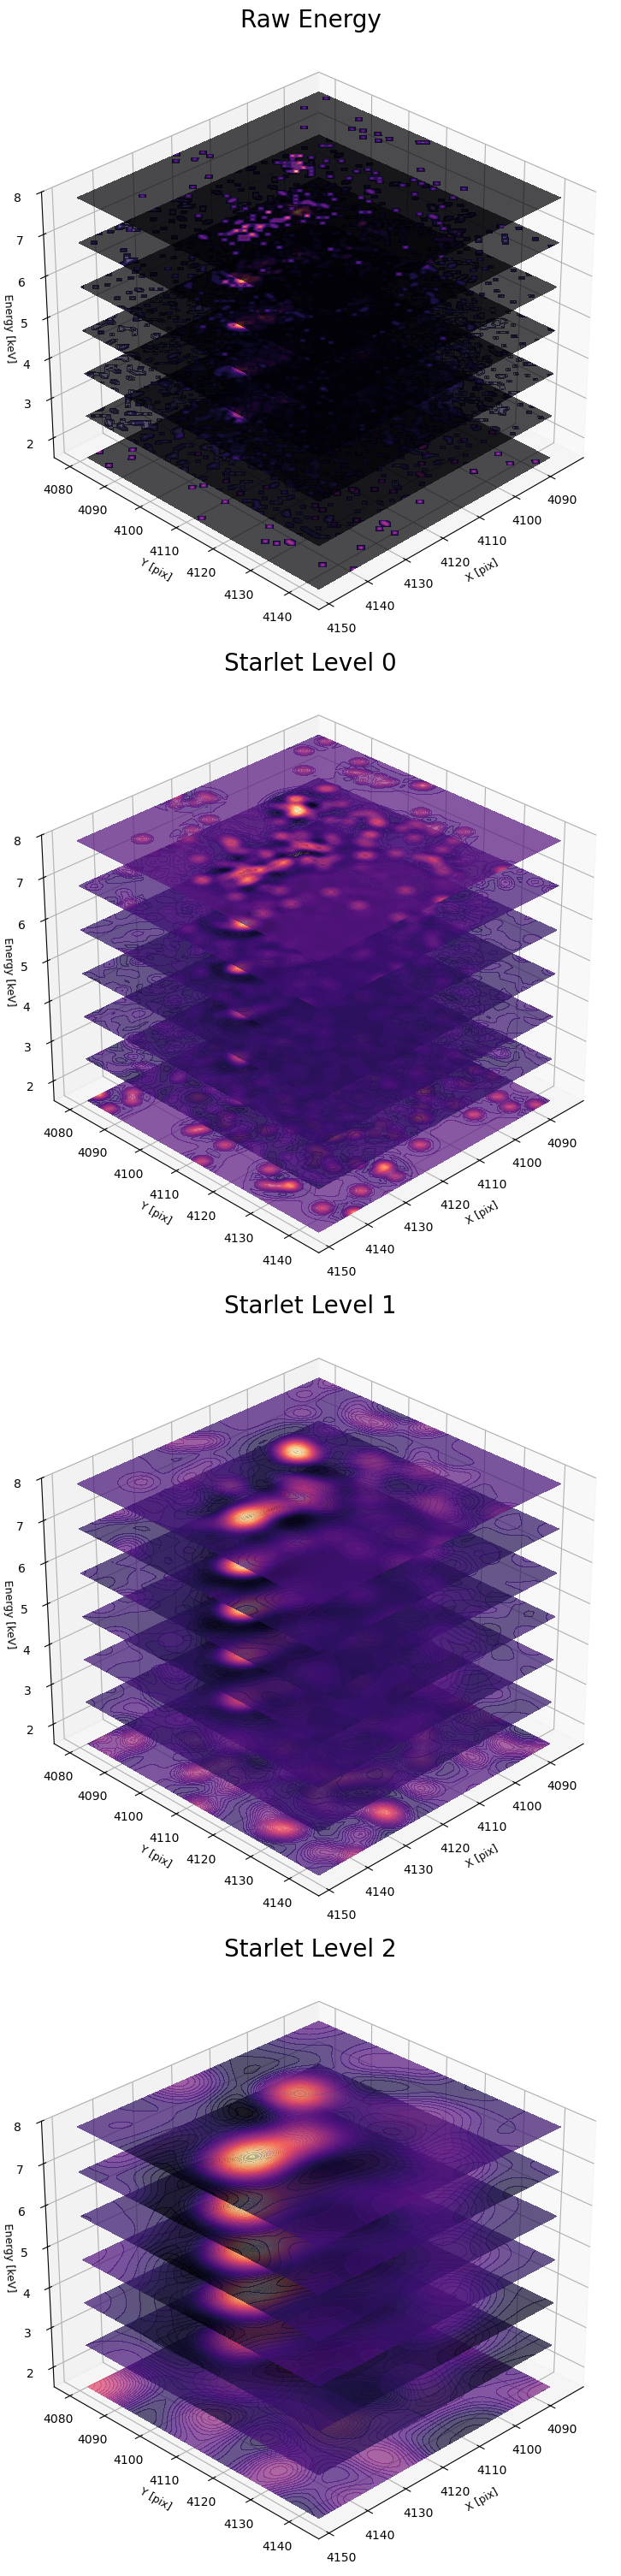

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Grid & Setup ---
channels = [0, 1, 2, 3]
labels = ['Raw Energy', 'Starlet Level 0', 'Starlet Level 1', 'Starlet Level 2']

# Increase the figure height significantly to accommodate the vertical stack
fig = plt.figure(figsize=(10, 30), constrained_layout=True) 

# --- 2. Data Prep (Outside loop for efficiency) ---
total_bands = cube.shape[0]
energy_values = np.linspace(EMIN, EMAX, total_bands) / 1e3
skip = max(1, cube.shape[2] // BINX)
original_res = cube.shape[2]

x_coords = np.arange(XMIN, XMIN + original_res, skip)
y_coords = np.arange(YMIN, YMIN + cube.shape[3], skip)
X, Y = np.meshgrid(x_coords, y_coords)

# --- 3. The Multi-plot Loop ---
for idx, ch in enumerate(channels):
    # Create a vertical subplot: (rows=4, cols=1, current_index=idx+1)
    ax = fig.add_subplot(4, 1, idx + 1, projection='3d')
    
    step = 8
    for i in range(0, total_bands, step):
        actual_energy = energy_values[i]
        # Access [energy, channel, x, y] and downsample
        slice_data = cube[i, ch, ::skip, ::skip] 
        
        ax.contourf(X, Y, slice_data, 
                    zdir='z', 
                    offset=actual_energy, 
                    cmap='magma', 
                    levels=50, 
                    alpha=0.7)

    # --- Aesthetics for the "Clean" Look ---
    ax.set_title(labels[idx], fontsize=20)
    ax.set_zlim(energy_values.min(), energy_values.max())
    
    # Labelling and solving the cutoff issue
    ax.set_xlabel('X [pix]', fontsize=9)
    ax.set_ylabel('Y [pix]', fontsize=9)
    ax.set_zlabel('Energy [keV]', labelpad=-2, fontsize=9)
    
    # View adjustments
    ax.view_init(elev=30, azim=45)
    ax.set_box_aspect((1, 1, 0.8)) # Square base, equal height

# Space things out vertically
plt.subplots_adjust(hspace=0.05) 
plt.show()